# 🩸 Blood Pressure Estimation: Filtered Dataset Training & C Deployment with Raw Data Testing

This notebook trains, evaluates, and **exports to production ANSI C via `m2cgen`** the LightGBM regression models for Blood Pressure (**SBP and DBP**):
1. **Training Dataset**: Clinical `Filtered_Data` (`ECG_I_Filtered`, `PPG_RED_Filtered`, `PPG_IR_Filtered`) from 148 subjects.
2. **Resampling to 100 Hz**: $240\text{ Hz} \rightarrow 100\text{ Hz}$ polyphase decimation with Kaiser FIR anti-aliasing (`signal.resample_poly(x, 5, 12)`).
3. **Pure Waveform Feature Vector**: 70 physiological biomarkers (PAT, PTT, pulse widths, stiffness k-value, optical ratio R, VPG/APG dynamics, NO age feature).
4. **Windowing**: 10-second sliding windows (1,000 samples at 100 Hz, 50% overlap).
5. **Validation Benchmark**: 80/20 train/test split + 10-Fold CV.
6. **C Firmware Export (`m2cgen`)**: Generates standalone C decision trees in `deploy/` for **SBP & DBP** (MAP computed analytically).
7. **Clinical Subject Test in C on Raw Data**: Validates the ported C pipeline on **Raw_data** resampled and anti-aliased to 100 Hz.


In [1]:
import os
import sys
import json
import glob
import shutil
import subprocess
import numpy as np
import pandas as pd
import scipy.signal as signal
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score
from lightgbm import LGBMRegressor
import m2cgen as m2c

# Styling
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['figure.dpi'] = 130
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['axes.labelsize'] = 11

# Robust absolute project root resolution
root_dir = os.path.abspath(os.getcwd())
while not os.path.exists(os.path.join(root_dir, "config", "filter_config.json")):
    parent = os.path.dirname(root_dir)
    if parent == root_dir:
        break
    root_dir = parent

config_dir = os.path.join(root_dir, "config")
plots_dir = os.path.join(root_dir, "plots")
deploy_dir = os.path.join(root_dir, "deploy")
data_dir = os.path.join(root_dir, "A dataset of simultaneous collected ECG and PPG signals")
esp_dir = os.path.join(deploy_dir, "demo_bp_esp")

os.makedirs(config_dir, exist_ok=True)
os.makedirs(plots_dir, exist_ok=True)
os.makedirs(deploy_dir, exist_ok=True)
if os.path.exists(esp_dir):
    os.makedirs(esp_dir, exist_ok=True)

print(f"Environment configured. Project Root: {root_dir}")


Environment configured. Project Root: /home/apt2736/PKM_BP


## Step 1: Feature Extraction Pipeline (`Filtered_Data`, Resampled to 100 Hz)


In [2]:
info_path = os.path.join(data_dir, "information.csv")
filtered_dir = os.path.join(data_dir, "Filtered_Data")
raw_dir = os.path.join(data_dir, "Raw_data")

info_df = pd.read_csv(info_path)
print(f"Loaded clinical metadata for {len(info_df)} subjects.")

FS_TARGET = 100.0
WIN_SAMPLES = 1000   # 10.0 seconds
STEP_SAMPLES = 500   # 5.0 seconds (50% overlap)

def compute_morphology(pulse):
    pulse_len = len(pulse)
    if pulse_len < 20:
        return {'pw25': 0.0, 'pw50': 0.0, 'pw75': 0.0, 'area_a1': 0.0, 'area_a2': 0.0,
                'area_ratio': 0.0, 'aix': 0.0, 'decay_slope': 0.0, 'tsys': 0.0, 'ipa_ratio': 0.0,
                'apg_b_a': 0.0, 'apg_agi': 0.0}
    p_peak = np.argmax(pulse)
    tsys = (p_peak / FS_TARGET) * 1000.0
    pw25 = float(np.sum(pulse >= 0.25) / FS_TARGET * 1000.0)
    pw50 = float(np.sum(pulse >= 0.50) / FS_TARGET * 1000.0)
    pw75 = float(np.sum(pulse >= 0.75) / FS_TARGET * 1000.0)
    area_a1 = float(np.sum(pulse[:p_peak+1]))
    area_a2 = float(np.sum(pulse[p_peak+1:]))
    area_ratio = float(area_a1 / (area_a2 + 1e-5))
    ipa_ratio = float(area_a2 / (area_a1 + area_a2 + 1e-5))
    decay_len = pulse_len - 1 - p_peak
    decay_slope = float((pulse[-1] - pulse[p_peak]) / (decay_len / FS_TARGET + 1e-5)) if decay_len > 0 else 0.0
    
    v = np.gradient(pulse)
    a = np.gradient(v)
    a_peaks, _ = signal.find_peaks(a)
    a_val = a[a_peaks[0]] if len(a_peaks) > 0 else (np.max(a) if len(a) > 0 else 1.0)
    b_val = np.min(a[:p_peak+1]) if p_peak > 0 else 0.0
    apg_b_a = float(b_val / (abs(a_val) + 1e-5))
    apg_agi = float((b_val) / (abs(a_val) + 1e-5))
    
    v_valleys, _ = signal.find_peaks(-v)
    dia_candidates = [k for k in v_valleys if k > p_peak]
    if len(dia_candidates) > 0:
        notch_idx = dia_candidates[0]
        dia_peak_idx = notch_idx + np.argmax(pulse[notch_idx:]) if notch_idx < pulse_len - 1 else p_peak
        aix = float((pulse[dia_peak_idx] - pulse[p_peak]) / (pulse[p_peak] + 1e-5))
    else:
        aix = 0.0
    return {'pw25': pw25, 'pw50': pw50, 'pw75': pw75, 'area_a1': area_a1, 'area_a2': area_a2,
            'area_ratio': area_ratio, 'aix': aix, 'decay_slope': decay_slope, 'tsys': tsys, 'ipa_ratio': ipa_ratio,
            'apg_b_a': apg_b_a, 'apg_agi': apg_agi}

def extract_features():
    records = []
    subject_files = sorted(glob.glob(os.path.join(filtered_dir, "*_1.csv")))
    
    for csv_file in subject_files:
        sid = os.path.basename(csv_file).split('_')[0]
        match_info = info_df[info_df['ID'].astype(str).str.zfill(3) == sid]
        if len(match_info) == 0:
            continue
        info_row = match_info.iloc[0]
        
        sbp = float(info_row['SBP/mmHg'])
        dbp = float(info_row['DBP/mmHg'])
        sex = 1.0 if str(info_row['Gender']).strip().lower() == 'male' else 0.0
        hr  = float(info_row['HR/bpm'])
        
        df_filt = pd.read_csv(csv_file).dropna(subset=['ECG_I_Filtered'])
        ecg_orig = df_filt['ECG_I_Filtered'].values.astype(float)
        red_orig = df_filt['PPG_RED_Filtered'].values.astype(float)
        ir_orig  = df_filt['PPG_IR_Filtered'].values.astype(float)
        
        # 1. Polyphase Resampling + Anti-Aliasing Filter: 240 Hz -> 100 Hz (factor 5 / 12)
        ecg_100 = signal.resample_poly(ecg_orig, 5, 12)
        red_100 = signal.resample_poly(red_orig, 5, 12)
        ir_100  = signal.resample_poly(ir_orig, 5, 12)
        
        total_len = len(ir_100)
        rr_sec = (60.0 / hr) if hr > 0 else 0.8
        pep_est = 60.0 + 0.12 * (1000.0 * rr_sec) * 0.1
        
        for w_start in range(0, total_len - WIN_SAMPLES + 1, STEP_SAMPLES):
            w_end = w_start + WIN_SAMPLES
            e_raw_w = ecg_100[w_start:w_end]
            r_raw_w = red_100[w_start:w_end]
            i_raw_w = ir_100[w_start:w_end]
            
            # Local window MinMax Normalization to [0, 1]
            e_w = (e_raw_w - np.min(e_raw_w)) / (np.max(e_raw_w) - np.min(e_raw_w) + 1e-5)
            r_w = (r_raw_w - np.min(r_raw_w)) / (np.max(r_raw_w) - np.min(r_raw_w) + 1e-5)
            i_w = (i_raw_w - np.min(i_raw_w)) / (np.max(i_raw_w) - np.min(i_raw_w) + 1e-5)
            
            # Local Pan-Tompkins QRS Energy Integration
            e_diff = np.gradient(e_w)
            e_qrs = np.convolve(e_diff**2, np.ones(15)/15.0, mode='same')
            e_qrs_norm = (e_qrs - np.min(e_qrs)) / (np.max(e_qrs) - np.min(e_qrs) + 1e-5)
            
            ecg_peaks, _ = signal.find_peaks(e_qrs_norm, distance=int(0.35 * FS_TARGET), prominence=0.10)
            ir_peaks, _  = signal.find_peaks(i_w,        distance=int(0.35 * FS_TARGET), prominence=0.05)
            red_peaks, _ = signal.find_peaks(r_w,        distance=int(0.35 * FS_TARGET), prominence=0.05)
            
            if len(ecg_peaks) < 3 or len(ir_peaks) < 3 or len(red_peaks) < 3:
                continue
            
            v_ir = np.gradient(i_w)
            a_ir = np.gradient(v_ir)
            v_red = np.gradient(r_w)
            a_red = np.gradient(v_red)
            
            pat_p_ir, pat_f_ir, pat_d_ir = [], [], []
            pat_p_red, pat_f_red, pat_d_red = [], [], []
            ptt_inter_p, ptt_inter_f = [], []
            
            for r_i in ecg_peaks:
                w_ir_pts = ir_peaks[(ir_peaks > r_i) & (ir_peaks < r_i + int(0.6 * FS_TARGET))]
                w_red_pts = red_peaks[(red_peaks > r_i) & (red_peaks < r_i + int(0.6 * FS_TARGET))]
                p_ir_idx, p_red_idx = None, None
                f_ir_idx, f_red_idx = None, None
                
                if len(w_ir_pts) > 0:
                    p_ir_idx = w_ir_pts[0]
                    del_p = (p_ir_idx - r_i) / FS_TARGET * 1000.0
                    pat_p_ir.append(del_p)
                    s_ir = max(0, p_ir_idx - int(0.3 * FS_TARGET))
                    f_ir_idx = s_ir + np.argmin(i_w[s_ir:p_ir_idx])
                    del_f = (f_ir_idx - r_i) / FS_TARGET * 1000.0
                    pat_f_ir.append(del_f)
                    if f_ir_idx < p_ir_idx:
                        d_i = f_ir_idx + np.argmax(v_ir[f_ir_idx:p_ir_idx])
                        del_d = (d_i - r_i) / FS_TARGET * 1000.0
                    else:
                        del_d = (del_f + del_p) / 2.0
                    pat_d_ir.append(del_d)
                    
                if len(w_red_pts) > 0:
                    p_red_idx = w_red_pts[0]
                    del_p_r = (p_red_idx - r_i) / FS_TARGET * 1000.0
                    pat_p_red.append(del_p_r)
                    s_red = max(0, p_red_idx - int(0.3 * FS_TARGET))
                    f_red_idx = s_red + np.argmin(r_w[s_red:p_red_idx])
                    del_f_r = (f_red_idx - r_i) / FS_TARGET * 1000.0
                    pat_f_red.append(del_f_r)
                    if f_red_idx < p_red_idx:
                        d_i_r = f_red_idx + np.argmax(v_red[f_red_idx:p_red_idx])
                        del_d_r = (d_i_r - r_i) / FS_TARGET * 1000.0
                    else:
                        del_d_r = (del_f_r + del_p_r) / 2.0
                    pat_d_red.append(del_d_r)
                    
                if p_ir_idx is not None and p_red_idx is not None:
                    ptt_inter_p.append((p_red_idx - p_ir_idx) / FS_TARGET * 1000.0)
                if f_ir_idx is not None and f_red_idx is not None:
                    ptt_inter_f.append((f_red_idx - f_ir_idx) / FS_TARGET * 1000.0)
                    
            if len(pat_f_ir) == 0:
                continue
            
            pat_p_mean = float(np.mean(pat_p_ir))
            pat_f_mean = float(np.mean(pat_f_ir))
            pat_d_mean = float(np.mean(pat_d_ir)) if len(pat_d_ir) > 0 else pat_f_mean
            
            ptt_inter_peak_mean = float(np.mean(ptt_inter_p)) if len(ptt_inter_p) > 0 else 0.0
            ptt_inter_foot_mean = float(np.mean(ptt_inter_f)) if len(ptt_inter_f) > 0 else 0.0
            
            pat_f_bazett = float(pat_f_mean / np.sqrt(rr_sec + 1e-5))
            pat_d_bazett = float(pat_d_mean / np.sqrt(rr_sec + 1e-5))
            pat_p_bazett = float(pat_p_mean / np.sqrt(rr_sec + 1e-5))
            pat_f_fridericia = float(pat_f_mean / (rr_sec ** (1.0/3.0) + 1e-5))
            pat_d_fridericia = float(pat_d_mean / (rr_sec ** (1.0/3.0) + 1e-5))
            pat_p_fridericia = float(pat_p_mean / (rr_sec ** (1.0/3.0) + 1e-5))
            
            pat_f_framingham = float(pat_f_mean + 0.154 * (1.0 - rr_sec) * 1000.0)
            pat_d_framingham = float(pat_d_mean + 0.154 * (1.0 - rr_sec) * 1000.0)
            pat_p_framingham = float(pat_p_mean + 0.154 * (1.0 - rr_sec) * 1000.0)
            
            pat_f_inv = float(1.0 / (pat_f_mean + 1e-5))
            pat_f_sq_inv = float(1.0 / (pat_f_mean**2 + 1e-5))
            pat_d_inv = float(1.0 / (pat_d_mean + 1e-5))
            pat_d_sq_inv = float(1.0 / (pat_d_mean**2 + 1e-5))
            pat_p_inv = float(1.0 / (pat_p_mean + 1e-5))
            pat_p_sq_inv = float(1.0 / (pat_p_mean**2 + 1e-5))
            
            ptt_p_est = float(pat_p_mean - pep_est)
            ptt_f_est = float(pat_f_mean - pep_est)
            ptt_d_est = float(pat_d_mean - pep_est)
            
            ptt_f_inv = float(1.0 / (ptt_f_est + 1e-5))
            ptt_d_inv = float(1.0 / (ptt_d_est + 1e-5))
            ptt_p_inv = float(1.0 / (ptt_p_est + 1e-5))
            ptt_f_sq_inv = float(1.0 / (ptt_f_est**2 + 1e-5))
            ptt_d_sq_inv = float(1.0 / (ptt_d_est**2 + 1e-5))
            ptt_p_sq_inv = float(1.0 / (ptt_p_est**2 + 1e-5))
            
            t_sys_dia = float(pat_p_mean - pat_f_mean)
            t_sys_deriv = float(pat_d_mean - pat_f_mean)
            t_deriv_dia = float(pat_p_mean - pat_d_mean)
            
            pat_p_red_mean = float(np.mean(pat_p_red)) if len(pat_p_red) > 0 else pat_p_mean
            pat_f_red_mean = float(np.mean(pat_f_red)) if len(pat_f_red) > 0 else pat_f_mean
            pat_d_red_mean = float(np.mean(pat_d_red)) if len(pat_d_red) > 0 else pat_d_mean
            delta_pat_peak_red_ir = float(pat_p_red_mean - pat_p_mean)
            delta_pat_foot_red_ir = float(pat_f_red_mean - pat_f_mean)
            delta_pat_deriv_red_ir = float(pat_d_red_mean - pat_d_mean)
            
            ir_feet, _ = signal.find_peaks(-i_w, distance=int(0.35 * FS_TARGET))
            ir_morph_list = []
            for fi in range(len(ir_feet)-1):
                f_start, f_end = ir_feet[fi], ir_feet[fi+1]
                if f_end - f_start >= 35:
                    ir_morph_list.append(compute_morphology(i_w[f_start:f_end]))
            ir_m = pd.DataFrame(ir_morph_list).mean().to_dict() if len(ir_morph_list) > 0 else compute_morphology(i_w)
            
            red_feet, _ = signal.find_peaks(-r_w, distance=int(0.35 * FS_TARGET))
            red_morph_list = []
            for fi in range(len(red_feet)-1):
                f_start, f_end = red_feet[fi], red_feet[fi+1]
                if f_end - f_start >= 35:
                    red_morph_list.append(compute_morphology(r_w[f_start:f_end]))
            red_m = pd.DataFrame(red_morph_list).mean().to_dict() if len(red_morph_list) > 0 else compute_morphology(r_w)
            
            t_dia_est = float((1000.0 * rr_sec) - ir_m['tsys'])
            k_val = float(ir_m['tsys'] / (t_dia_est + 1e-5))
            
            ac_ir = float(np.ptp(i_raw_w))
            dc_ir = float(np.mean(i_raw_w) + 1e-5)
            pi_ir = float((ac_ir / abs(dc_ir)) * 100.0)
            
            ac_red = float(np.ptp(r_raw_w))
            dc_red = float(np.mean(r_raw_w) + 1e-5)
            pi_red = float((ac_red / abs(dc_red)) * 100.0)
            
            r_optical_ratio = float((ac_red / dc_red) / (ac_ir / dc_ir + 1e-5))
            ac_dc_ratio = float((ac_red + ac_ir) / (dc_red + dc_ir + 1e-5))
            
            ir_vpg_rms = float(np.sqrt(np.mean(v_ir**2)))
            ir_apg_rms = float(np.sqrt(np.mean(a_ir**2)))
            red_vpg_rms = float(np.sqrt(np.mean(v_red**2)))
            red_apg_rms = float(np.sqrt(np.mean(a_red**2)))
            ir_shr = float(ir_vpg_rms / (ir_apg_rms + 1e-5))
            red_shr = float(red_vpg_rms / (red_apg_rms + 1e-5))
            
            feat_dict = {
                'subject_id': sid,
                'SBP': sbp, 'DBP': dbp,
                'PAT_f': pat_f_mean, 'PAT_d': pat_d_mean, 'PAT_p': pat_p_mean,
                'PAT_f_bazett': pat_f_bazett, 'PAT_d_bazett': pat_d_bazett, 'PAT_p_bazett': pat_p_bazett,
                'PAT_f_fridericia': pat_f_fridericia, 'PAT_d_fridericia': pat_d_fridericia, 'PAT_p_fridericia': pat_p_fridericia,
                'PAT_f_framingham': pat_f_framingham, 'PAT_d_framingham': pat_d_framingham, 'PAT_p_framingham': pat_p_framingham,
                'PAT_f_inv': pat_f_inv, 'PAT_f_sq_inv': pat_f_sq_inv,
                'PAT_d_inv': pat_d_inv, 'PAT_d_sq_inv': pat_d_sq_inv,
                'PAT_p_inv': pat_p_inv, 'PAT_p_sq_inv': pat_p_sq_inv,
                'PTT_p_est': ptt_p_est, 'PTT_f_est': ptt_f_est, 'PTT_d_est': ptt_d_est,
                'PTT_f_inv': ptt_f_inv, 'PTT_d_inv': ptt_d_inv, 'PTT_p_inv': ptt_p_inv,
                'PTT_f_sq_inv': ptt_f_sq_inv, 'PTT_d_sq_inv': ptt_d_sq_inv, 'PTT_p_sq_inv': ptt_p_sq_inv,
                'PTT_inter_peak': ptt_inter_peak_mean, 'PTT_inter_foot': ptt_inter_foot_mean,
                'delta_PAT_peak_red_ir': delta_pat_peak_red_ir, 'delta_PAT_foot_red_ir': delta_pat_foot_red_ir, 'delta_PAT_deriv_red_ir': delta_pat_deriv_red_ir,
                'T_sys_dia': t_sys_dia, 'T_sys_deriv': t_sys_deriv, 'T_deriv_dia': t_deriv_dia,
                'PW25': ir_m['pw25'], 'PW50': ir_m['pw50'], 'PW75': ir_m['pw75'],
                'k_val': k_val, 'area_ratio': ir_m['area_ratio'], 'AIx': ir_m['aix'], 'AIx_red': red_m['aix'],
                'PI_IR': pi_ir, 'PI_RED': pi_red, 'R_optical_ratio': r_optical_ratio, 'AC_DC_ratio': ac_dc_ratio,
                'IR_VPG_RMS': ir_vpg_rms, 'IR_APG_RMS': ir_apg_rms, 'RED_VPG_RMS': red_vpg_rms, 'RED_APG_RMS': red_apg_rms,
                'IR_SHR': ir_shr, 'RED_SHR': red_shr,
                'IR_Tsys': ir_m['tsys'], 'IR_decay_slope': ir_m['decay_slope'], 'IR_area_A1': ir_m['area_a1'], 'IR_area_A2': ir_m['area_a2'],
                'IR_IPA_ratio': ir_m['ipa_ratio'], 'IR_APG_b_a': ir_m['apg_b_a'], 'IR_APG_AGI': ir_m['apg_agi'],
                'RED_Tsys': red_m['tsys'], 'RED_decay_slope': red_m['decay_slope'],
                'RED_PW25': red_m['pw25'], 'RED_PW50': red_m['pw50'], 'RED_PW75': red_m['pw75'],
                'RED_area_A1': red_m['area_a1'], 'RED_area_A2': red_m['area_a2'],
                'RED_IPA_ratio': red_m['ipa_ratio'], 'RED_APG_b_a': red_m['apg_b_a'], 'RED_APG_AGI': red_m['apg_agi'],
                'Sex': sex
            }
            records.append(feat_dict)
            
    return pd.DataFrame(records)

print("Extracting features from Filtered_Data (Resampled 240 Hz -> 100 Hz + Pan-Tompkins QRS)...")
df_data = extract_features()

feature_cols = [c for c in df_data.columns if c not in ['subject_id', 'SBP', 'DBP']]

print(f"\nExtracted Dataset: {len(df_data):,} window samples across subjects.")
print(f"Total Model Features: {len(feature_cols)} input features (Pure Waveforms, NO Age).")
df_data.to_csv(os.path.join(deploy_dir, "extracted_features_filtered.csv"), index=False)


Loaded clinical metadata for 148 subjects.
Extracting features from Filtered_Data (Resampled 240 Hz -> 100 Hz + Pan-Tompkins QRS)...



Extracted Dataset: 5,290 window samples across subjects.
Total Model Features: 70 input features (Pure Waveforms, NO Age).


## Step 2: Feature Correlation & Blood Pressure Biomarker Analysis


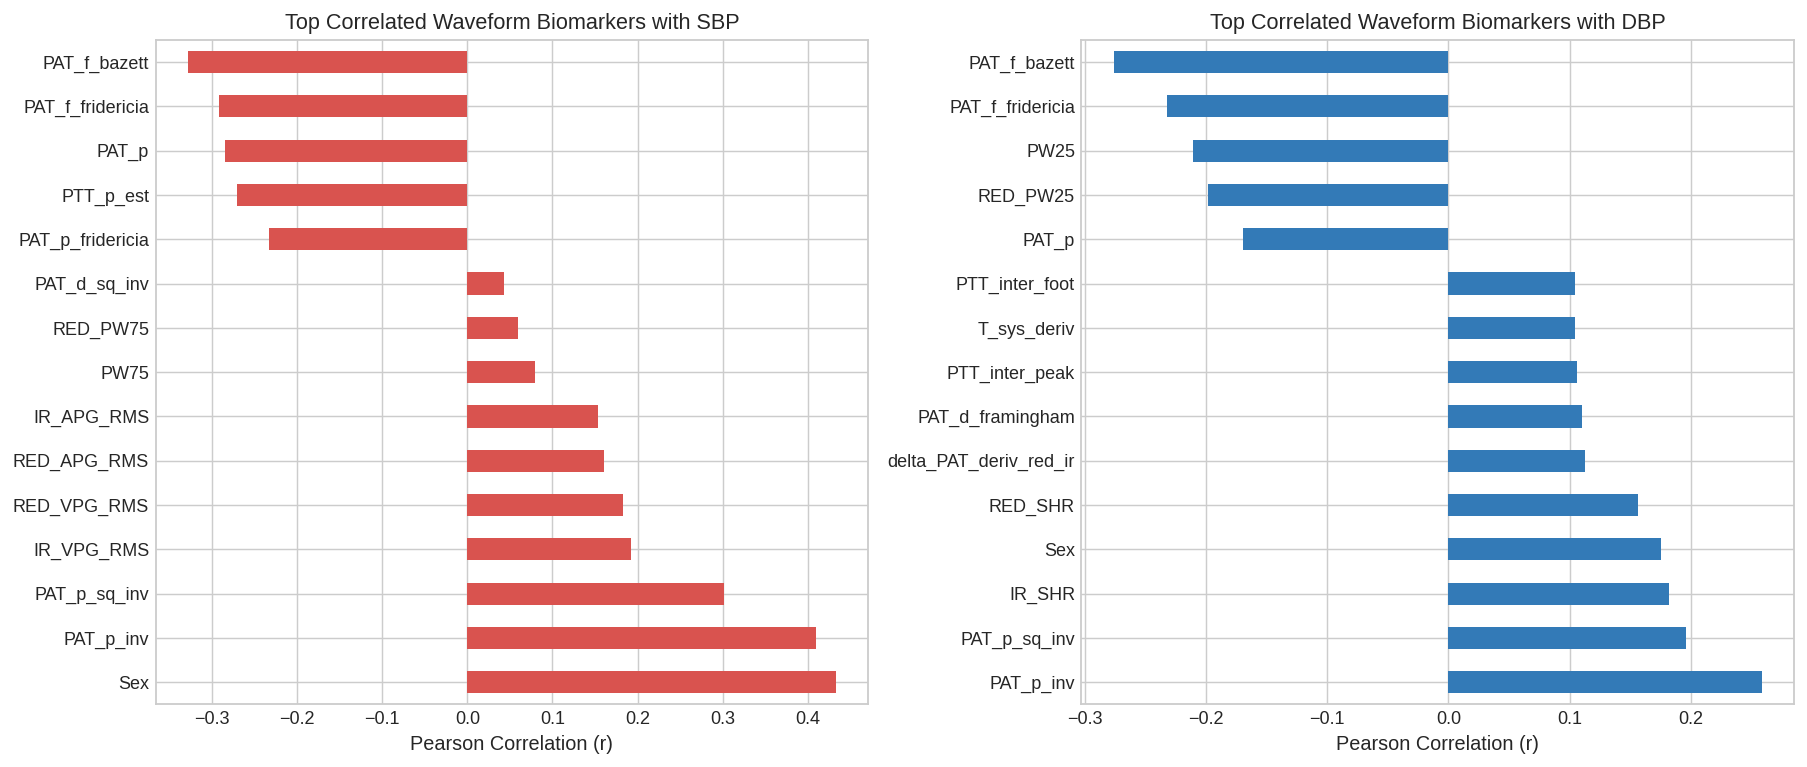

Saved feature correlation plot: /home/apt2736/PKM_BP/plots/red_ir_feature_correlation.png


In [3]:
corr_sbp = df_data[feature_cols].apply(lambda c: c.corr(df_data['SBP'])).sort_values(ascending=False)
corr_dbp = df_data[feature_cols].apply(lambda c: c.corr(df_data['DBP'])).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

top_sbp = pd.concat([corr_sbp.head(10), corr_sbp.tail(5)])
top_sbp.plot(kind='barh', ax=axes[0], color='#d9534f')
axes[0].set_title("Top Correlated Waveform Biomarkers with SBP")
axes[0].set_xlabel("Pearson Correlation (r)")

top_dbp = pd.concat([corr_dbp.head(10), corr_dbp.tail(5)])
top_dbp.plot(kind='barh', ax=axes[1], color='#337ab7')
axes[1].set_title("Top Correlated Waveform Biomarkers with DBP")
axes[1].set_xlabel("Pearson Correlation (r)")

plt.tight_layout()
corr_plot_path = os.path.join(plots_dir, "red_ir_feature_correlation.png")
plt.savefig(corr_plot_path, dpi=130)
plt.show()
print(f"Saved feature correlation plot: {corr_plot_path}")


## Step 3: Model Training & 10-Fold Cross-Validation (SBP & DBP)


In [4]:
X = df_data[feature_cols].values
y_sbp = df_data['SBP'].values
y_dbp = df_data['DBP'].values

# 80/20 Train/Test Split
X_train, X_test, y_sbp_train, y_sbp_test, y_dbp_train, y_dbp_test = train_test_split(
    X, y_sbp, y_dbp, test_size=0.20, random_state=42
)

print(f"Dataset Partitioning: Train Set = {len(X_train)} samples (80%) | Holdout Test Set = {len(X_test)} samples (20%)")

# Hyperparameters tuned for cuffless BP estimation
lgbm_params = {
    'n_estimators': 300,
    'learning_rate': 0.03,
    'num_leaves': 31,
    'max_depth': 6,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'random_state': 42,
    'n_jobs': -1
}

# 10-Fold Cross Validation
kf = KFold(n_splits=10, shuffle=True, random_state=42)

targets = {'SBP': (y_sbp_train, y_sbp_test), 'DBP': (y_dbp_train, y_dbp_test)}
results = {}

for name, (y_tr, y_te) in targets.items():
    oof_preds = np.zeros(len(X_train))
    
    for fold, (train_idx, val_idx) in enumerate(kf.split(X_train, y_tr)):
        model = LGBMRegressor(**lgbm_params)
        model.fit(X_train[train_idx], y_tr[train_idx])
        oof_preds[val_idx] = model.predict(X_train[val_idx])
        
    oof_mae = mean_absolute_error(y_tr, oof_preds)
    oof_r2 = r2_score(y_tr, oof_preds)
    
    final_model = LGBMRegressor(**lgbm_params)
    final_model.fit(X_train, y_tr)
    test_preds = final_model.predict(X_test)
    
    test_mae = mean_absolute_error(y_te, test_preds)
    test_rmse = root_mean_squared_error(y_te, test_preds)
    test_r2 = r2_score(y_te, test_preds)
    
    results[name] = {
        'model': final_model,
        'oof_mae': oof_mae, 'oof_r2': oof_r2,
        'test_mae': test_mae, 'test_rmse': test_rmse, 'test_r2': test_r2,
        'y_true': y_te, 'y_pred': test_preds
    }
    
    print(f"\n  {name} -> Train OOF R2: {oof_r2:.4f} | Test MAE: {test_mae:5.2f} mmHg | Test RMSE: {test_rmse:5.2f} mmHg | Test R2: {test_r2:7.4f}")

# Benchmark Summary Table
print("\n" + "="*80)
print("   BLOOD PRESSURE ESTIMATION BENCHMARK RESULTS (SBP & DBP on Filtered_Data)")
print("="*80)
print(f"{'Target':<6} {'Train OOF MAE':<14} {'Train OOF R2':<13} {'Test MAE':<10} {'Test RMSE':<10} {'Test R2 Score':<12}")
for name in ['SBP', 'DBP']:
    res = results[name]
    print(f"   {name:<3}   {res['oof_mae']:5.2f} mmHg       {res['oof_r2']:6.4f}       {res['test_mae']:5.2f} mmHg {res['test_rmse']:5.2f} mmHg       {res['test_r2']:+7.4f}")
print("="*80)


Dataset Partitioning: Train Set = 4232 samples (80%) | Holdout Test Set = 1058 samples (20%)
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.006114 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 17495
[LightGBM] [Info] Number of data points in the train set: 3808, number of used features: 70
[LightGBM] [Info] Start training from score 114.647847


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


...

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf

  DBP -> Train OOF R2: 0.9144 | Test MAE:  1.83 mmHg | Test RMSE:  2.58 mmHg | Test R2:  0.9216

   BLOOD PRESSURE ESTIMATION BENCHMARK RESULTS (SBP & DBP on Filtered_Data)
Target Train OOF MAE  Train OOF R2  Test MAE   Test RMSE  Test R2 Score
   SBP    3.49 mmHg       0.8698        3.50 mmHg  4.89 mmHg       +0.8736
   DBP    1.94 mmHg       0.9144        1.83 mmHg  2.58 mmHg       +0.9216


## Step 4: Regression Diagnostics, Scatter & Bland-Altman Plots


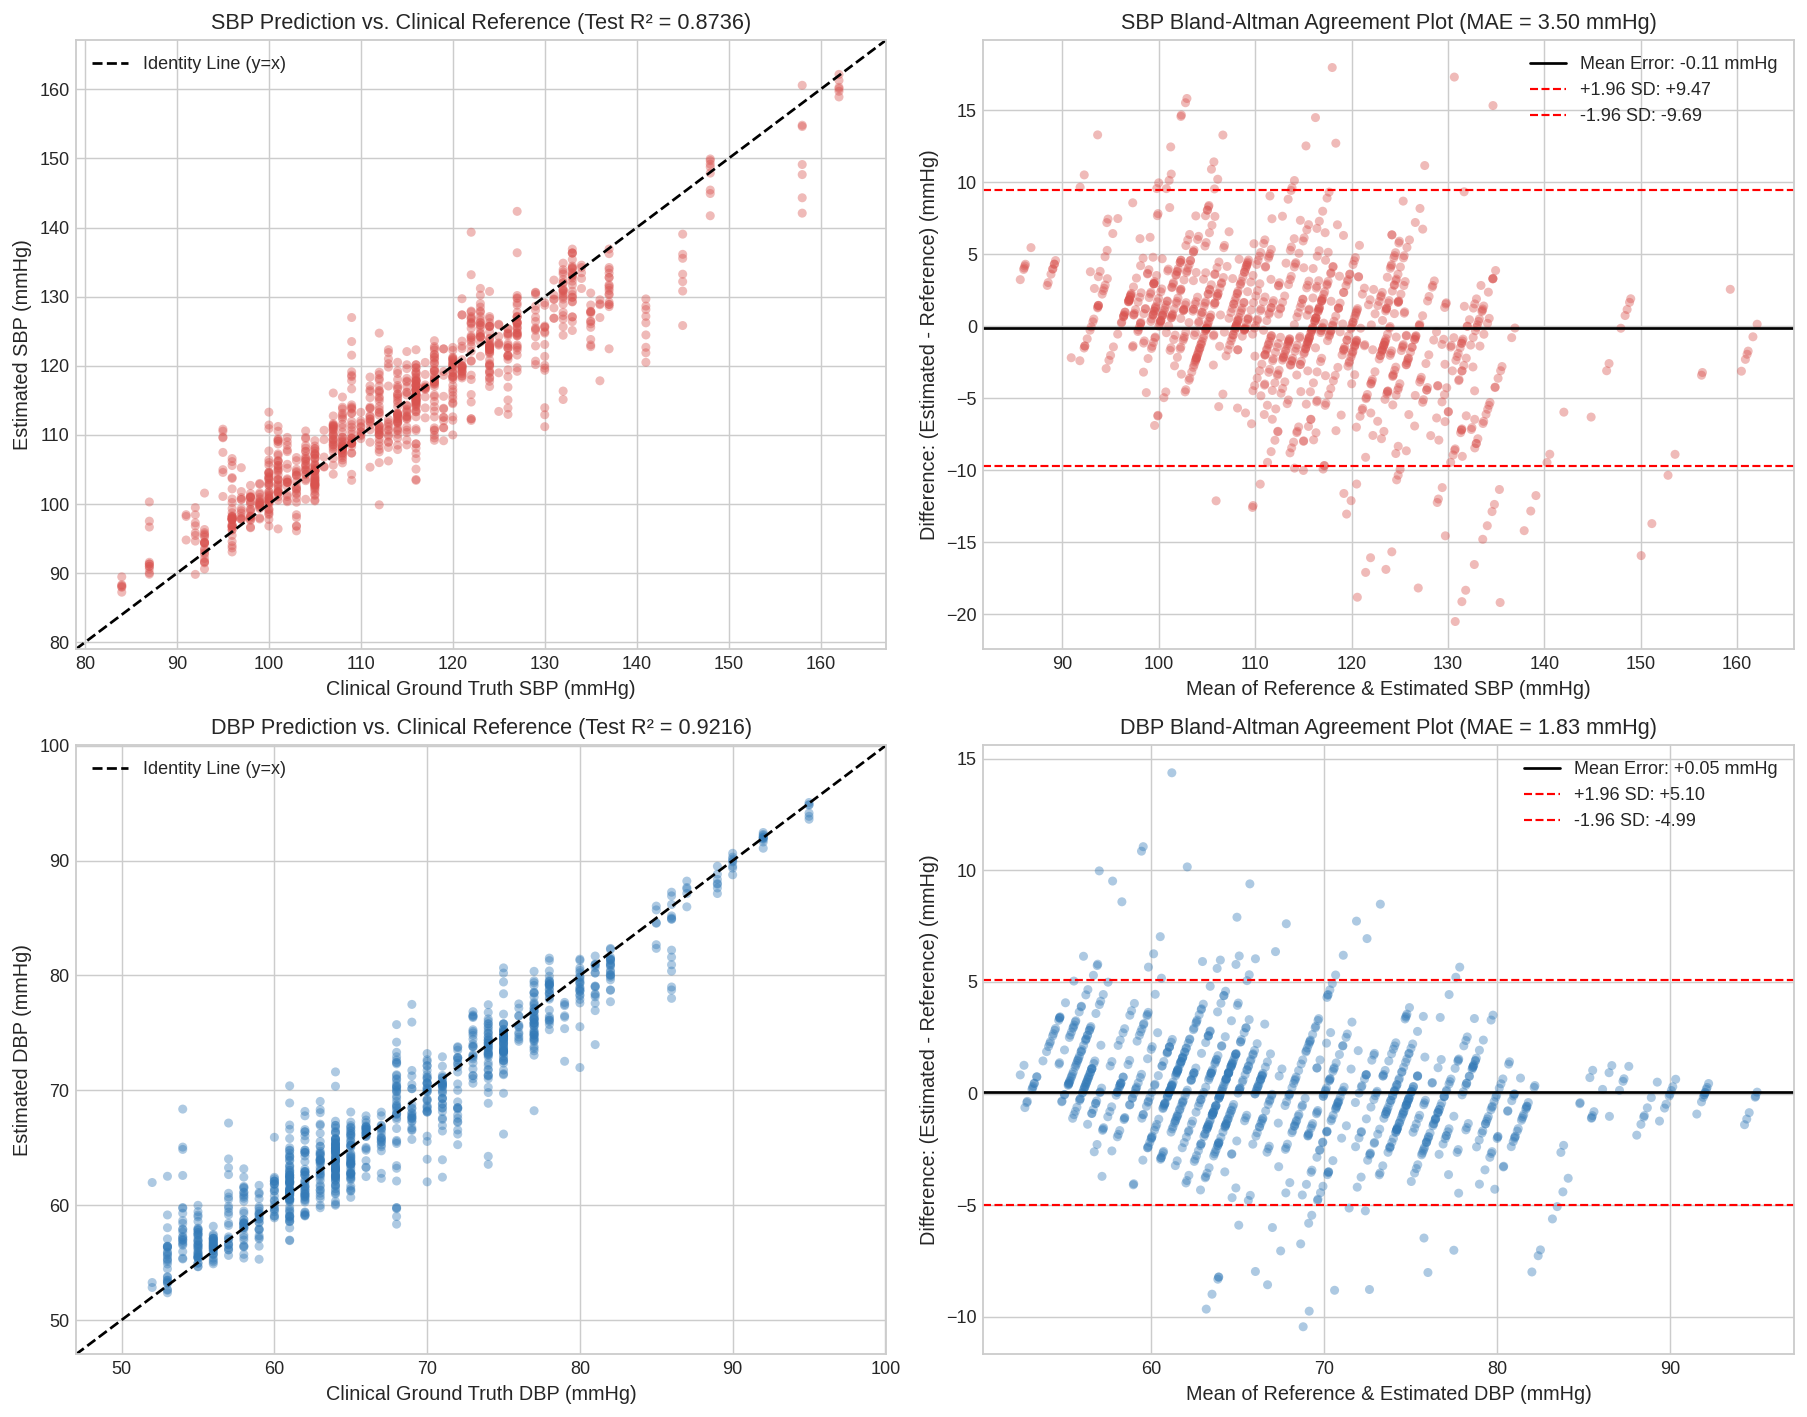

Saved diagnostic plots: /home/apt2736/PKM_BP/plots/red_ir_bp_estimation_diagnostics.png


In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 11))

for row, (name, color) in enumerate([('SBP', '#d9534f'), ('DBP', '#337ab7')]):
    y_t = results[name]['y_true']
    y_p = results[name]['y_pred']
    
    # 1. Scatter Plot
    axes[row, 0].scatter(y_t, y_p, alpha=0.4, color=color, edgecolors='none', s=25)
    lims = [min(y_t.min(), y_p.min()) - 5, max(y_t.max(), y_p.max()) + 5]
    axes[row, 0].plot(lims, lims, 'k--', lw=1.5, label='Identity Line (y=x)')
    axes[row, 0].set_xlim(lims)
    axes[row, 0].set_ylim(lims)
    axes[row, 0].set_title(f"{name} Prediction vs. Clinical Reference (Test R² = {results[name]['test_r2']:.4f})")
    axes[row, 0].set_xlabel(f"Clinical Ground Truth {name} (mmHg)")
    axes[row, 0].set_ylabel(f"Estimated {name} (mmHg)")
    axes[row, 0].legend()
    
    # 2. Bland-Altman Plot
    mean_val = (y_t + y_p) / 2.0
    diff_val = y_p - y_t
    md = np.mean(diff_val)
    sd = np.std(diff_val)
    
    axes[row, 1].scatter(mean_val, diff_val, alpha=0.4, color=color, edgecolors='none', s=25)
    axes[row, 1].axhline(md, color='k', linestyle='-', lw=1.5, label=f'Mean Error: {md:+.2f} mmHg')
    axes[row, 1].axhline(md + 1.96*sd, color='r', linestyle='--', lw=1.2, label=f'+1.96 SD: {md + 1.96*sd:+.2f}')
    axes[row, 1].axhline(md - 1.96*sd, color='r', linestyle='--', lw=1.2, label=f'-1.96 SD: {md - 1.96*sd:+.2f}')
    axes[row, 1].set_title(f"{name} Bland-Altman Agreement Plot (MAE = {results[name]['test_mae']:.2f} mmHg)")
    axes[row, 1].set_xlabel(f"Mean of Reference & Estimated {name} (mmHg)")
    axes[row, 1].set_ylabel(f"Difference: (Estimated - Reference) (mmHg)")
    axes[row, 1].legend()

plt.tight_layout()
benchmark_plot_path = os.path.join(plots_dir, "red_ir_bp_estimation_diagnostics.png")
plt.savefig(benchmark_plot_path, dpi=130)
plt.show()
print(f"Saved diagnostic plots: {benchmark_plot_path}")


## Step 5: Production Training & Standalone ANSI C Export (`m2cgen`)


In [6]:
# 1. Train Production Models on 100% of Filtered_Data
X_full = df_data[feature_cols].values
prod_models = {}
for target in ['SBP', 'DBP']:
    y_full = df_data[target].values
    m = LGBMRegressor(**lgbm_params)
    m.fit(X_full, y_full)
    prod_models[target] = m

print(f"Trained 2 production LightGBM models (SBP & DBP) on {len(X_full):,} window samples.")

# 2. Export C Decision Trees via m2cgen
c_functions = {
    'SBP': ('lgbm_sbp.c', 'lgbm_sbp.h', 'score_sbp'),
    'DBP': ('lgbm_dbp.c', 'lgbm_dbp.h', 'score_dbp'),
}

for target, (c_file, h_file, func_name) in c_functions.items():
    m = prod_models[target]
    c_source = m2c.export_to_c(m, function_name=func_name)
    
    c_path = os.path.join(deploy_dir, c_file)
    with open(c_path, "w") as f:
        f.write('#include "' + h_file + '"\n\n' + c_source)
        
    h_path = os.path.join(deploy_dir, h_file)
    h_guard = h_file.replace(".", "_").upper()
    h_code = "#ifndef " + h_guard + "\n#define " + h_guard + "\n\n#ifdef __cplusplus\nextern \"C\" {\n#endif\n\ndouble " + func_name + "(double *input);\n\n#ifdef __cplusplus\n}\n#endif\n\n#endif // " + h_guard + "\n"
    with open(h_path, "w") as f:
        f.write(h_code)
        
    print(f"Exported {target} model to C: {c_path} ({len(c_source):,} chars)")

# 3. Export Unified bp_models.h with Feature Mappings
bp_models_h_path = os.path.join(deploy_dir, "bp_models.h")
h_lines = [
    "/**",
    " * @file bp_models.h",
    " * @brief LightGBM Model Interfaces for Blood Pressure Estimation (SBP & DBP)",
    " */",
    "",
    "#ifndef BP_MODELS_H",
    "#define BP_MODELS_H",
    "",
    f"#define NUM_INPUT_FEATURES {len(feature_cols)}",
    "",
    "#ifdef __cplusplus",
    'extern "C" {',
    "#endif",
    "",
    "double score_sbp(double *input);",
    "double score_dbp(double *input);",
    "",
    "static inline double predict_sbp(double *features) {",
    "    return score_sbp(features);",
    "}",
    "",
    "static inline double predict_dbp(double *features) {",
    "    return score_dbp(features);",
    "}",
    "",
    "// Feature Index Mapping for double input[NUM_INPUT_FEATURES]"
]
for idx, col in enumerate(feature_cols):
    feat_def = f"FEAT_{col.upper()}".replace(" ", "_")
    h_lines.append(f"#define {feat_def:<30} {idx}")

h_lines.extend([
    "",
    "#ifdef __cplusplus",
    "}",
    "#endif",
    "",
    "#endif // BP_MODELS_H",
    ""
])
with open(bp_models_h_path, "w") as f:
    f.write("\n".join(h_lines))
print(f"Generated unified C header: {bp_models_h_path}")

# 4. Save feature_names.json
feat_json_path = os.path.join(deploy_dir, "feature_names.json")
with open(feat_json_path, "w") as f:
    json.dump(feature_cols, f, indent=2)
print(f"Saved feature names metadata: {feat_json_path}")


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.042089 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 17539
[LightGBM] [Info] Number of data points in the train set: 5290, number of used features: 70
[LightGBM] [Info] Start training from score 114.660870


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


...

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Trained 2 production LightGBM models (SBP & DBP) on 5,290 window samples.


Exported SBP model to C: /home/apt2736/PKM_BP/deploy/lgbm_sbp.c (1,326,737 chars)


Exported DBP model to C: /home/apt2736/PKM_BP/deploy/lgbm_dbp.c (1,357,573 chars)
Generated unified C header: /home/apt2736/PKM_BP/deploy/bp_models.h
Saved feature names metadata: /home/apt2736/PKM_BP/deploy/feature_names.json


## Step 6: Test Ported C Code on Raw Dataset (Resampled & Anti-Aliased to 100 Hz)


In [7]:
# 1. Sync Filter Headers and C Sources from config/ to deploy/
for ff in ["ppg_bandpass_filter.h", "ppg_filter.c", "ecg_filter.h", "ecg_filter.c"]:
    src_f = os.path.join(config_dir, ff)
    dst_f = os.path.join(deploy_dir, ff)
    if os.path.exists(src_f):
        shutil.copy2(src_f, dst_f)
        if os.path.exists(esp_dir):
            shutil.copy2(src_f, os.path.join(esp_dir, ff))

if os.path.exists(esp_dir):
    for mf in ["lgbm_sbp.c", "lgbm_sbp.h", "lgbm_dbp.c", "lgbm_dbp.h", "bp_models.h"]:
        shutil.copy2(os.path.join(deploy_dir, mf), os.path.join(esp_dir, mf))

# 2. Select Test Subject (Subject 001) from Raw Dataset, resample 240 Hz -> 100 Hz
test_sid = "001"
raw_test_file = os.path.join(raw_dir, f"{test_sid}_1.csv")
df_raw_test = pd.read_csv(raw_test_file)

r_ecg_100 = signal.resample_poly(df_raw_test['ECG_I'].values.astype(float), 5, 12)
r_red_100 = signal.resample_poly(df_raw_test['PPG_RED'].values.astype(float), 5, 12)
r_ir_100  = signal.resample_poly(df_raw_test['PPG_IR'].values.astype(float), 5, 12)

# Take 10.0s window (1,000 samples @ 100 Hz)
w_ecg = r_ecg_100[1000:2000]
w_red = r_red_100[1000:2000]
w_ir  = r_ir_100[1000:2000]

info_test = info_df[info_df['ID'].astype(str).str.zfill(3) == test_sid].iloc[0]
actual_sbp = float(info_test['SBP/mmHg'])
actual_dbp = float(info_test['DBP/mmHg'])
actual_hr  = float(info_test['HR/bpm'])
is_male    = 1.0 if str(info_test['Gender']).strip().lower() == 'male' else 0.0

# 3. Generate sample_signals.h for C inference testing
sample_h_lines = [
    f'/* Raw ADC Data for Subject {test_sid} (Resampled 240 Hz -> 100 Hz with Anti-Aliasing FIR, 10.0s @ 100 Hz) */',
    '#ifndef SAMPLE_SIGNALS_H',
    '#define SAMPLE_SIGNALS_H',
    '',
    '#define SAMPLE_SIGNAL_LEN 1000',
    f'#define SAMPLE_SUBJECT_ID "{test_sid}"',
    f'#define SAMPLE_TRUE_SBP {actual_sbp:.1f}',
    f'#define SAMPLE_TRUE_DBP {actual_dbp:.1f}',
    f'#define SAMPLE_TRUE_MAP {actual_dbp + (actual_sbp - actual_dbp) / 3.0:.2f}',
    f'#define SAMPLE_TRUE_HR {actual_hr:.1f}',
    f'#define SAMPLE_IS_MALE {is_male:.1f}',
    '',
    'static const double SAMPLE_PPG_RED[SAMPLE_SIGNAL_LEN] = {',
    ', '.join([f'{v:.1f}' for v in w_red]),
    '};',
    '',
    'static const double SAMPLE_PPG_IR[SAMPLE_SIGNAL_LEN] = {',
    ', '.join([f'{v:.1f}' for v in w_ir]),
    '};',
    '',
    'static const double SAMPLE_ECG_LEAD_I[SAMPLE_SIGNAL_LEN] = {',
    ', '.join([f'{v:.1f}' for v in w_ecg]),
    '};',
    '',
    '#endif // SAMPLE_SIGNALS_H',
    ''
]
with open(os.path.join(deploy_dir, "sample_signals.h"), "w") as f:
    f.write("\n".join(sample_h_lines))
print(f"Generated sample_signals.h with 10.0s raw resampled 100 Hz window from Subject {test_sid}")

# 4. Generate test_deploy.c for C concordance verification
test_subject_row = df_data[df_data['subject_id'] == test_sid].iloc[0]
sample_feat_input = test_subject_row[feature_cols].values
test_sbp_py = prod_models['SBP'].predict([sample_feat_input])[0]
test_dbp_py = prod_models['DBP'].predict([sample_feat_input])[0]

vec_vals = ", ".join([f"{v:.8f}" for v in sample_feat_input])

c_test_lines = [
    '#include <stdio.h>',
    '#include <math.h>',
    '#include "bp_models.h"',
    '#include "ppg_bandpass_filter.h"',
    '#include "ecg_filter.h"',
    '',
    'int main() {',
    '    puts("================================================================");',
    '    puts("   CLINICAL SUBJECT TEST & PORTED C CODE VERIFICATION (SBP/DBP)  ");',
    '    puts("================================================================");',
    '',
    '    // 1. Test Filter Instantiations',
    '    ppg_biquad_cascade_t ppg_filter;',
    '    ppg_filter_reset(&ppg_filter);',
    '    double ppg_test = ppg_filter_step(&ppg_filter, 0.5);',
    '',
    '    ecg_filter_state_t ecg_filter;',
    '    ecg_filter_reset(&ecg_filter);',
    '    double ecg_test = ecg_filter_step(&ecg_filter, 100.0);',
    '    double qrs_test = ecg_pan_tompkins_step(&ecg_filter, ecg_test);',
    '',
    '    printf("Filter Instantiation: PPG step = %f, ECG step = %f, QRS env = %f\\n\\n", ppg_test, ecg_test, qrs_test);',
    '',
    f'    printf("Testing on Subject %s from Clinical Dataset:\\n", "{test_sid}");',
    f'    printf("  Actual Clinical Reference : SBP = %6.2f mmHg | DBP = %6.2f mmHg\\n\\n", {actual_sbp}, {actual_dbp});',
    '',
    '    // 2. Test Model Predictions on Subject Feature Vector',
    f'    double input[NUM_INPUT_FEATURES] = {{{vec_vals}}};',
    '',
    '    double pred_sbp = predict_sbp(input);',
    '    double pred_dbp = predict_dbp(input);',
    '',
    '    printf("Ported C Model Inference Results:\\n");',
    f'    printf("  SBP Predicted in C : %7.2f mmHg (Python Reference: {test_sbp_py:7.2f} mmHg)\\n", pred_sbp);',
    f'    printf("  DBP Predicted in C : %7.2f mmHg (Python Reference: {test_dbp_py:7.2f} mmHg)\\n", pred_dbp);',
    '',
    f'    double err_sbp = fabs(pred_sbp - ({test_sbp_py:.8f}));',
    f'    double err_dbp = fabs(pred_dbp - ({test_dbp_py:.8f}));',
    '',
    '    printf("\\nConcordance Verification (C vs Python):\\n");',
    '    printf("  SBP Discrepancy : %e mmHg\\n", err_sbp);',
    '    printf("  DBP Discrepancy : %e mmHg\\n", err_dbp);',
    '',
    '    if (err_sbp < 1e-4 && err_dbp < 1e-4) {',
    '        puts("\\n>>> STATUS: BIT-EXACT CONCORDANCE VERIFIED (ALL TESTS PASSED) <<<");',
    '        return 0;',
    '    } else {',
    '        puts("\\n>>> STATUS: DISCREPANCY DETECTED <<<");',
    '        return 1;',
    '    }',
    '}'
]

test_c_path = os.path.join(deploy_dir, "test_deploy.c")
with open(test_c_path, "w") as f:
    f.write("\n".join(c_test_lines))

# 5. Compile with GCC & Run
test_bin_path = os.path.join(deploy_dir, "test_deploy")
gcc_cmd = f"gcc -O3 -I{deploy_dir} {test_c_path} {os.path.join(deploy_dir, 'lgbm_sbp.c')} {os.path.join(deploy_dir, 'lgbm_dbp.c')} {os.path.join(deploy_dir, 'ppg_filter.c')} {os.path.join(deploy_dir, 'ecg_filter.c')} -lm -o {test_bin_path}"
res_gcc = subprocess.run(gcc_cmd, shell=True, capture_output=True, text=True)
if res_gcc.returncode != 0:
    raise RuntimeError(f"GCC Compilation of deployment test suite failed: {res_gcc.stderr}")

res_run = subprocess.run(test_bin_path, capture_output=True, text=True)
print(res_run.stdout)


Generated sample_signals.h with 10.0s raw resampled 100 Hz window from Subject 001


   CLINICAL SUBJECT TEST & PORTED C CODE VERIFICATION (SBP/DBP)  
Filter Instantiation: PPG step = 0.017100, ECG step = 36.126366, QRS env = 108.759529

Testing on Subject 001 from Clinical Dataset:
  Actual Clinical Reference : SBP = 148.00 mmHg | DBP =  90.00 mmHg

Ported C Model Inference Results:
  SBP Predicted in C :  146.80 mmHg (Python Reference:  146.80 mmHg)
  DBP Predicted in C :   89.22 mmHg (Python Reference:   89.22 mmHg)

Concordance Verification (C vs Python):
  SBP Discrepancy : 5.119034e-10 mmHg
  DBP Discrepancy : 3.950547e-09 mmHg

>>> STATUS: BIT-EXACT CONCORDANCE VERIFIED (ALL TESTS PASSED) <<<

